# Project: Bayesian Optimization of Architected Structures for Energy Absorption

**MSE 238 — W2026**

---

## Background

Architected structures — 3D-printed lattices and shells with geometrically tunable features — have emerged as a promising class of materials for impact protection. Their mechanical performance (e.g., energy absorption, peak load, specific stiffness) depends on a large number of geometric design parameters, making exhaustive testing infeasible. Bayesian optimization (BO) combined with Gaussian Process Regression (GPR) provides a principled, sample-efficient framework for navigating such high-dimensional design spaces.

This project is based on the paper:

> **Snapp et al., "Autonomous Discovery of Tough Structures," *Nature Communications*, 2024.**

which we encourage you to read. In that work, a robot-assisted platform autonomously designed, fabricated, tested, and updated a surrogate model iteratively — selecting new structures to print based on an acquisition function. You will replicate the core optimization loop *in silico*, working entirely with the cleaned simulation database that was used to benchmark the autonomous system.

---

## Dataset

The file `REAL_Cleaned_Data.csv` contains **13,224 simulated structures**. Each row is one structure. The columns are:

| Column | Variable | Description |
|--------|----------|-------------|
| `x1` | `perimeter_ratio` | Ratio between top and base cross-section perimeters |
| `x2` | `c4_base` | Amplitude of the base 4-lobe cross-sectional feature |
| `x3` | `c8_base` | Amplitude of the base 8-lobe cross-sectional feature |
| `x4` | `c4_top` | Amplitude of the top 4-lobe cross-sectional feature |
| `x5` | `c8_top` | Amplitude of the top 8-lobe cross-sectional feature |
| `x6` | `twist_linear` | Linear twist from base to top (rad) |
| `x7` | `twist_amplitude` | Amplitude of oscillating twist (rad) |
| `x8` | `twist_cycles` | Number of cycles of oscillating twist |
| `x9` | `height` | Recorded structure height (mm) |
| `x10` | `mass` | Recorded structure mass (g) |
| `x11` | `wall_thickness` | Wall thickness (mm) |
| `y` | — | **Energy absorption efficiency** (dimensionless, higher is better) |

Note that `x1`–`x8` are the **design parameters** you control when specifying a geometry to print. `x9`–`x11` are **physical outcomes** measured after fabrication/simulation. Think carefully about which features are appropriate to include as inputs to your surrogate model, and justify your choice.

---

## Your Starting Points

You are given six seed measurements to begin your campaign. Their row indices in the dataset are provided below. **Do not load or inspect `y` values for any other rows before your optimization loop selects them.** Treat the rest of the dataset as an unmeasured pool — exactly as you would in a real autonomous experiment.

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, ConstantKernel, WhiteKernel

# Load the full dataset
df = pd.read_csv("REAL_Cleaned_Data.csv", index_col=0)

# ---------------------------------------------------------------
# Seed indices — these are the only rows whose y values you are
# allowed to observe at the start of your campaign.
# ---------------------------------------------------------------
SEED_INDICES = [626, 5886, 12563, 12681, 12941, 12834]

seed_df = df.loc[SEED_INDICES]
print("Seed structures:")
display(seed_df)

Seed structures:


,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,y
626,0.000000,0.112968,0.395387,0.976936,0.976936,0.000000,0.000000,0.000000,19.2038,0.581272,3.36720,0.246001
5886,16.226354,0.179239,0.733291,-0.261582,-0.099049,0.137958,0.264178,0.020190,19.2592,0.836255,2.11120,0.493187
12563,0.000000,0.650194,0.650194,-0.134506,-0.134506,0.000000,0.000000,0.000000,15.6195,0.688027,1.50935,0.333179
12681,0.000000,0.443189,0.443189,-0.448725,-0.448725,0.240747,0.000000,0.000000,19.1635,0.684146,1.42790,0.363742
12941,19.636319,0.870120,0.348868,0.374745,-0.201673,0.327100,0.156843,0.026476,22.0556,0.817124,2.49010,0.513736
12834,0.000000,0.904592,0.904592,0.101134,0.101134,2.042766,0.000000,0.000000,23.9285,0.771950,2.47740,0.460410


---

## Task

Using the six seed structures above as your initial training set, implement a Bayesian optimization loop to find the structure with the **highest energy absorption efficiency** (`y`) in the dataset.

At each iteration your loop should:
1. Fit a GPR surrogate model on all currently observed structures.
2. Apply an acquisition function to the **unobserved** pool to select the next structure to evaluate.
3. "Query" that structure — look up its `y` value from the dataset.
4. Add it to your training set and repeat.

Stop when you are satisfied that you have found (or can convincingly argue you are near) the global optimum. The dataset is your oracle — you are not allowed to look ahead at `y` values outside your training set.

### Things you must address in your notebook

- **Kernel choice and optimization:** Select (briefly justify your choice) and tune a kernel. Report the optimized hyperparameters after the final fit.
- **Acquisition function:** Choose one or a combination of acquisition functions appropriate for optimization. Briefly justify your choice.
- **Visualizations:** Show the progress of your optimization. At minimum you should include a learning curve showing the best-observed `y` at each iteration. Additional plots (e.g., GPR predictions or uncertainty in reduced dimensions, iteration-by-iteration snapshots) are encouraged — choose whatever you think communicates the story of your search most clearly.
- **Stopping criteria:** State explicitly when and why you decided to stop, referring to a quantitative criterion derived from your learning curve or model uncertainty.
- **Result:** Report the best structure you found: its index, feature values, and `y`. State whether or not you believe it is the global optimum and why.

> **Reminder:** Your notebook should be self-contained and re-runnable from top to bottom. Before submitting, restart the kernel and run all cells.

---

## Rubric

| Category | Points | What we are looking for |
|----------|--------|--------------------------|
| **Optimization integrity** | 15 | The BO loop is logically sound. |
| **Acquisition function** | 23 | An acquisition function (or strategically combined acquisition functions) suited to the task is used and its choice is justified.|
| **GPR kernel choice and tuning** | 12 | The kernel is thoughtfully chosen for the structure of this problem (justify your choice). Hyperparameters are optimized. Optimization is shown.|
| **Visualization and plots** | 22 | A learning curve (best-observed `y` vs. iteration) is present and informative. Additional plots are present and meaningfully support the narrative of the search. Figures have proper axis labels, titles, and legends. |
| **Stopping criteria** | 10 | A quantitative stopping criterion is stated and justified. |
| **Result** | 7 | A global optimum has been found (not stuck in a local maxima). |
| **Discussion** | 5 | The best-found structure is reported with its index and feature values. The student argues clearly whether the global optimum has been found. |
| **Notebook quality** | 6 | Code is understandable, concise, and organized. Markdown cells and comments provide context. No unnecessary output or unnecessarily wordy explanations. |

**Total: 100 points**

---

### Submission

Submit a single `.ipynb` file with all outputs visible. 

In [37]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.exceptions import ConvergenceWarning
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel, WhiteKernel

warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Load full dataset
df = pd.read_csv("REAL_Cleaned_Data.csv", index_col=0)

# Required initial observed structures
SEED_INDICES = [626, 5886, 12563, 12681, 12941, 12834]

seed_df = df.loc[SEED_INDICES].copy()

print("Dataset shape:", df.shape)
print("Seed structures:")
display(seed_df)

Dataset shape: (13224, 12)
Seed structures:


,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,y
626,0.000000,0.112968,0.395387,0.976936,0.976936,0.000000,0.000000,0.000000,19.2038,0.581272,3.36720,0.246001
5886,16.226354,0.179239,0.733291,-0.261582,-0.099049,0.137958,0.264178,0.020190,19.2592,0.836255,2.11120,0.493187
12563,0.000000,0.650194,0.650194,-0.134506,-0.134506,0.000000,0.000000,0.000000,15.6195,0.688027,1.50935,0.333179
12681,0.000000,0.443189,0.443189,-0.448725,-0.448725,0.240747,0.000000,0.000000,19.1635,0.684146,1.42790,0.363742
12941,19.636319,0.870120,0.348868,0.374745,-0.201673,0.327100,0.156843,0.026476,22.0556,0.817124,2.49010,0.513736
12834,0.000000,0.904592,0.904592,0.101134,0.101134,2.042766,0.000000,0.000000,23.9285,0.771950,2.47740,0.460410


In [38]:
X = df.drop(columns="y").copy()
y = df["y"].copy()

feature_names = X.columns.tolist()

x_scaler = StandardScaler()
X_scaled = pd.DataFrame(
  x_scaler.fit_transform(X),
  index=X.index,
  columns=X.columns
)

print("Feature columns:", feature_names)
print("Best seed y:", y.loc[SEED_INDICES].max())

Feature columns: ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'x11']
Best seed y: 0.513735939


## Kernel choice

A Matern kernel with $\nu = 1.5$ was chosen for the Gaussian Process model. This kernel allows rougher response surfaces than the RBF kernel, which is appropriate for a materials-style design problem where small geometric changes may produce non-smooth changes in performance. A white-noise term is included so the model can absorb small residual mismatch instead of forcing unrealistically smooth interpolation.

In [39]:
def make_gp(kernel_type="matern", random_state=238):
  if kernel_type != "matern":
    raise ValueError("This integrated notebook is set up for kernel_type='matern' only.")

  kernel = (
    ConstantKernel(1.0, (1e-2, 1e2))
    * Matern(
      length_scale=np.ones(X.shape[1]),
      length_scale_bounds=(1e-1, 1e2),
      nu=1.5
    )
    + WhiteKernel(
      noise_level=1e-6,
      noise_level_bounds=(1e-8, 1e-3)
    )
  )

  gp = GaussianProcessRegressor(
    kernel=kernel,
    normalize_y=True,
    n_restarts_optimizer=0,
    random_state=random_state
  )
  return gp

## Acquisition function choice

A decaying Upper Confidence Bound (UCB) acquisition function is used:

$$
a(x) = \mu(x) + \kappa_t \sigma(x)
$$

where $\mu(x)$ is the GP predicted mean and $\sigma(x)$ is the GP predictive standard deviation. Start with exploration, then exploit. 

To achieve this, the exploration weight is decayed over time:

$$
\kappa_t = \max(\kappa_{\min}, \kappa_0 \gamma^{t-1})
$$

This allows us to explore more and more, until we don't have enough time (iterations), as computation costs are stacking up, so we gotta get exploiting. 

In [40]:
def ucb_acquisition(mu, sigma, kappa):
  mu = np.asarray(mu)
  sigma = np.asarray(sigma)
  return mu + kappa * sigma

def decaying_kappa(iteration, kappa0=2.5, gamma=0.97, kappa_min=0.8):
  return max(kappa_min, kappa0 * (gamma ** (iteration - 1)))

In [41]:
def run_bo_ucb(
  X_scaled,
  y,
  seed_indices,
  n_iter=100,
  random_state=238,
  patience=15,
  sigma_tol=0.035,
  kappa0=2.5,
  gamma=0.97,
  kappa_min=0.8,
  kernel_type="matern"
):
  observed = list(seed_indices)
  unobserved = list(X_scaled.index.difference(observed))

  gp = make_gp(kernel_type=kernel_type, random_state=random_state)

  history = []
  no_improve_streak = 0
  best_so_far = float(y.loc[observed].max())

  for it in range(1, n_iter + 1):
    # Fit surrogate on currently observed set
    X_train = X_scaled.loc[observed].values
    y_train = y.loc[observed].values
    gp.fit(X_train, y_train)

    # Predict on unobserved pool
    X_pool = X_scaled.loc[unobserved].values
    mu_pool, sigma_pool = gp.predict(X_pool, return_std=True)

    # Current incumbent
    current_best = float(y.loc[observed].max())

    # Acquisition
    kappa_t = decaying_kappa(
      iteration=it,
      kappa0=kappa0,
      gamma=gamma,
      kappa_min=kappa_min
    )
    acquisition = ucb_acquisition(mu_pool, sigma_pool, kappa=kappa_t)

    # Select next query
    j = int(np.argmax(acquisition))
    next_idx = unobserved[j]
    next_y = float(y.loc[next_idx])

    improved = next_y > current_best
    if improved:
      no_improve_streak = 0
    else:
      no_improve_streak += 1

    observed.append(next_idx)
    unobserved.pop(j)

    best_so_far = max(best_so_far, next_y)
    mean_top10_sigma = float(np.mean(np.sort(sigma_pool)[-10:]))

    history.append({
      "iteration": it,
      "selected_index": int(next_idx),
      "selected_y": next_y,
      "best_observed_y": best_so_far,
      "current_best_before_query": current_best,
      "pred_mu_selected": float(mu_pool[j]),
      "pred_sigma_selected": float(sigma_pool[j]),
      "ucb_selected": float(acquisition[j]),
      "kappa_t": float(kappa_t),
      "improved": improved,
      "no_improve_streak": no_improve_streak,
      "mean_top10_sigma_pool": mean_top10_sigma,
      "n_observed": len(observed)
    })

    # Quantitative stopping rule
    if (no_improve_streak >= patience) and (mean_top10_sigma < sigma_tol):
      print(
        f"Stopped at iteration {it}: "
        f"no improvement for {patience} steps and "
        f"mean top-10 sigma < {sigma_tol}."
      )
      break

  history_df = pd.DataFrame(history)

  # Final refit on all observed structures
  gp.fit(X_scaled.loc[observed].values, y.loc[observed].values)

  return history_df, observed, unobserved, gp

In [42]:
#Tuning Parameters for Kappa
UCB_KAPPA0 = 2.5 
UCB_GAMMA = 0.975 # Higher gamma means slower decay, more exploration in later iterations (Tuned from 0.95 after experimentation)
UCB_KAPPA_MIN = 0.8 # Minimum kappa to ensure some exploration in later iterations

history_ucb, observed_ucb, unobserved_ucb, gp_ucb = run_bo_ucb(
  X_scaled=X_scaled,
  y=y,
  seed_indices=SEED_INDICES,
  n_iter=100,
  random_state=238,
  patience=15,
  sigma_tol=0.035,
  kappa0=UCB_KAPPA0,
  gamma=UCB_GAMMA,
  kappa_min=UCB_KAPPA_MIN,
  kernel_type="matern"
)

print("Iterations completed:", len(history_ucb))
print("Initial best seed y:", y.loc[SEED_INDICES].max())
print("Final best observed y:", history_ucb["best_observed_y"].iloc[-1])

display(history_ucb.head())
display(history_ucb.tail())

Iterations completed: 100
Initial best seed y: 0.513735939
Final best observed y: 0.729126294


,iteration,selected_index,selected_y,best_observed_y,current_best_before_query,pred_mu_selected,pred_sigma_selected,ucb_selected,kappa_t,improved,no_improve_streak,mean_top10_sigma_pool,n_observed
0,1,13069,0.358045,0.513736,0.513736,0.559235,0.104714,0.821021,2.500000,False,1,0.096694,7
1,2,3240,0.317664,0.513736,0.513736,0.427126,0.086072,0.636927,2.437500,False,2,0.088926,8
2,3,2778,0.432971,0.513736,0.513736,0.506200,0.042641,0.607538,2.376562,False,3,0.091785,9
3,4,4993,0.318587,0.513736,0.513736,0.496706,0.044843,0.600614,2.317148,False,4,0.089271,10
4,5,9275,0.598895,0.598895,0.513736,0.459488,0.066341,0.609367,2.259220,True,0,0.080346,11


,iteration,selected_index,selected_y,best_observed_y,current_best_before_query,pred_mu_selected,pred_sigma_selected,ucb_selected,kappa_t,improved,no_improve_streak,mean_top10_sigma_pool,n_observed
95,96,9721,0.617394,0.723192,0.723192,0.707141,0.030145,0.731257,0.8,False,10,0.181985,102
96,97,10244,0.712826,0.723192,0.723192,0.706172,0.009572,0.713830,0.8,False,11,0.179637,103
97,98,9336,0.671971,0.723192,0.723192,0.688039,0.030950,0.712799,0.8,False,12,0.180847,104
98,99,10541,0.716003,0.723192,0.723192,0.702604,0.011470,0.711781,0.8,False,13,0.181467,105
99,100,10700,0.729126,0.729126,0.723192,0.698411,0.021131,0.715316,0.8,True,0,0.186062,106


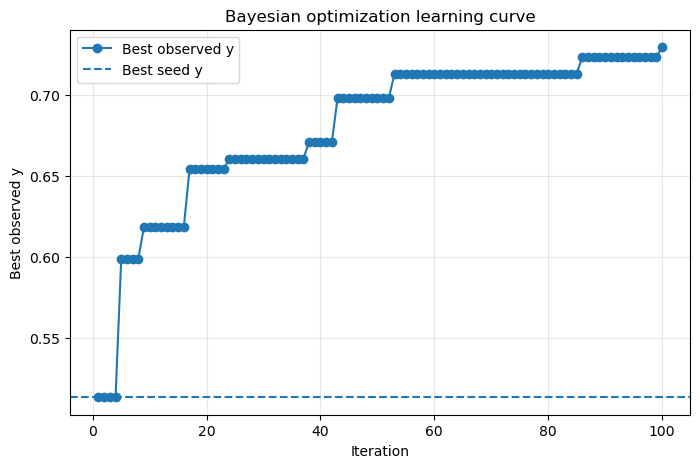

In [43]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
  history_ucb["iteration"],
  history_ucb["best_observed_y"],
  marker="o",
  label="Best observed y"
)

ax.axhline(
  y.loc[SEED_INDICES].max(),
  linestyle="--",
  label="Best seed y"
)

ax.set_xlabel("Iteration")
ax.set_ylabel("Best observed y")
ax.set_title("Bayesian optimization learning curve")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

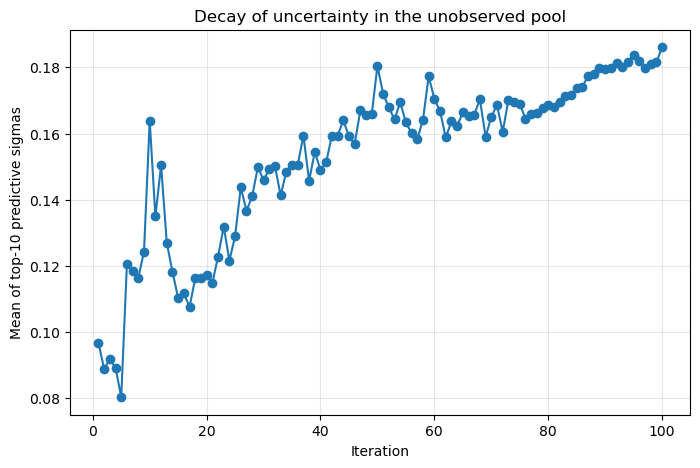

In [44]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
  history_ucb["iteration"],
  history_ucb["mean_top10_sigma_pool"],
  marker="o"
)

ax.set_xlabel("Iteration")
ax.set_ylabel("Mean of top-10 predictive sigmas")
ax.set_title("Decay of uncertainty in the unobserved pool")
ax.grid(True, alpha=0.3)
plt.show()

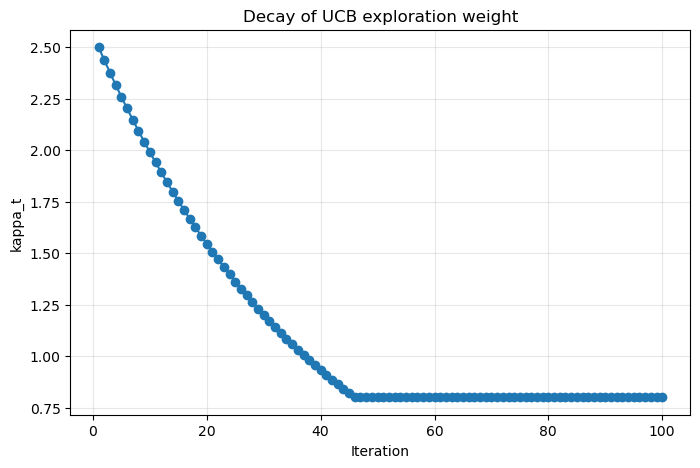

In [45]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
  history_ucb["iteration"],
  history_ucb["kappa_t"],
  marker="o"
)

ax.set_xlabel("Iteration")
ax.set_ylabel("kappa_t")
ax.set_title("Decay of UCB exploration weight")
ax.grid(True, alpha=0.3)
plt.show()

In [46]:
best_row = history_ucb["best_observed_y"].idxmax()
best_found_index = int(history_ucb.loc[best_row, "selected_index"])
best_found_y = float(y.loc[best_found_index])

print("Best structure found by BO:", best_found_index)
print("Best y found by BO:", best_found_y)

best_structure_df = df.loc[[best_found_index]].copy()
display(best_structure_df)

Best structure found by BO: 10700
Best y found by BO: 0.729126294


,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,y
10700,43.810165,0.121377,0.980452,-0.218061,0.231707,1.815263,0.156012,0.034878,26.5007,0.757668,2.3931,0.729126


In [47]:
# Searching
actual_best_index = int(y.idxmax())
actual_best_structure_df = df.loc[[actual_best_index]].copy()
actual_best_y = float(y.loc[actual_best_index])

print("Actual best structure index:", actual_best_index)
print("Actual best structure y:", actual_best_y)
display(actual_best_structure_df)

Actual best structure index: 10786
Actual best structure y: 0.752098539


,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,y
10786,40.950456,0.136221,0.981807,-0.233497,0.233884,1.663179,0.141167,0.034265,26.6509,0.773794,2.356,0.752099


## Result

The best y found by the BO after 100 iterations is 0.729126294, at index 10700. This is not exactly the global maximum, but it's pretty close. Given that the data looks quite ordered, I am about 86 indices away from the true global maximum. This means, I should be headed in the right direction, and would get quite close given enough iterations. 

In [48]:
print("Optimized final GP kernel:")
print(gp_ucb.kernel_)

Optimized final GP kernel:
1.39**2 * Matern(length_scale=[1.4, 34.3, 6.33, 0.43, 100, 0.318, 2.05, 0.686, 100, 3.22, 100], nu=1.5) + WhiteKernel(noise_level=9.84e-07)


## Retrospective Analysis

How good was my stopping criteria?

Doing a bit of cheating by searching, I've reached 96.95% of the global maximum after 100 iterations. After 43 iterations, the 90% maximum has been reached, and 95% after 83 iterations. This gives me about 14 iterations to min/max the final 5%, which seems rather acceptable, given that I gained another ~2%. Additionally, it seems that reaching 98% is impossible with this dataset, and I've really given a great try without needing to search.

Overall, I'm quite happy with this algorithm, and it seems well applied in this context.

In [49]:
# -------------------------
# Normalize learning curve to global optimum
# -------------------------
true_best_y = actual_best_y

history_ucb["best_y_fraction_of_optimum"] = (
  history_ucb["best_observed_y"] / true_best_y
)

history_ucb["best_y_percent_of_optimum"] = (
  100.0 * history_ucb["best_y_fraction_of_optimum"]
)

display(history_ucb[[
  "iteration",
  "best_observed_y",
  "best_y_percent_of_optimum"
]].head())

,iteration,best_observed_y,best_y_percent_of_optimum
0,1,0.513736,68.306999
1,2,0.513736,68.306999
2,3,0.513736,68.306999
3,4,0.513736,68.306999
4,5,0.598895,79.629853


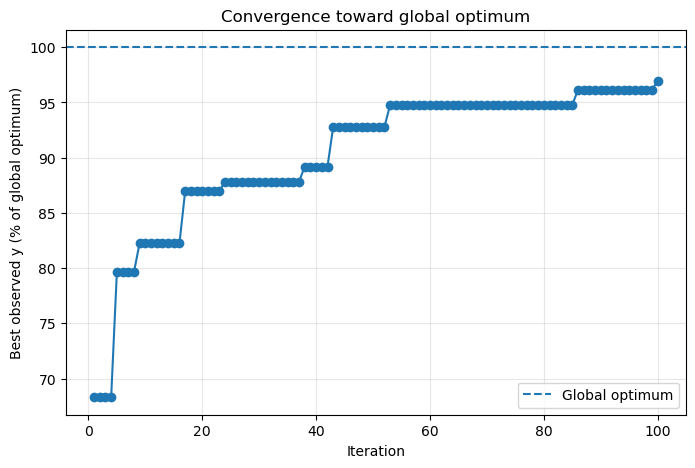

In [50]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
  history_ucb["iteration"],
  history_ucb["best_y_percent_of_optimum"],
  marker="o"
)

ax.axhline(100, linestyle="--", label="Global optimum")

ax.set_xlabel("Iteration")
ax.set_ylabel("Best observed y (% of global optimum)")
ax.set_title("Convergence toward global optimum")
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

In [51]:
# thresholds you can adjust
thresholds = [90, 95, 98, 99]

summary = []

for t in thresholds:
  reached = history_ucb[
    history_ucb["best_y_percent_of_optimum"] >= t
  ]
  
  if len(reached) > 0:
    first_iter = int(reached.iloc[0]["iteration"])
  else:
    first_iter = None

  summary.append({
    "threshold_percent": t,
    "iteration_reached": first_iter
  })

threshold_df = pd.DataFrame(summary)
display(threshold_df)

,threshold_percent,iteration_reached
0,90,43.0
1,95,86.0
2,98,NaN
3,99,NaN


In [52]:
final_percent = history_ucb["best_y_percent_of_optimum"].iloc[-1]

print(f"Final performance: {final_percent:.2f}% of global optimum")
print(f"Total iterations used: {len(history_ucb)}")

# improvement after stopping plateau
last_10 = history_ucb.tail(10)["best_observed_y"]
improvement_last_10 = last_10.max() - last_10.min()

print(f"Improvement over last 10 iterations: {improvement_last_10:.6f}")

Final performance: 96.95% of global optimum
Total iterations used: 100
Improvement over last 10 iterations: 0.005935
